In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
# Import the dataframe
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")

# Inspect the Data
print("Shape of the dataset:", df.shape)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst five rows:")
display(df.head())

print("\nLast five rows:")
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nRow names:")
print(df.index.tolist())

Shape of the dataset: (20, 11)
Number of rows: 20
Number of columns: 11

First five rows:


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3



Last five rows:


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown



Column names:
['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto']

Row names:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [7]:
# Extract Orbital period (row 0)
orbital_period = df.iloc[0, 1:].astype(float)   # row, then skip name column
print("\nOrbital Period values:")
print(orbital_period)

# Extract Perihelion (row 1)
perihelion = df.iloc[1, 1:].astype(float)
print("\nPerihelion values:")
print(perihelion)

# Extract Aphelion (row 2)
aphelion = df.iloc[2, 1:].astype(float)
print("\nAphelion values:")
print(aphelion)

# Perihelion is the position of the object's orbit where they are the closest to each other.
# Aphelion is the posiont of the object's orbit where it is farthest from the sun.
# Semi-major axis is measured by adding the perihelion and aphelion and dividing it by two.


Orbital Period values:
Mercury       0.330
Venus         4.870
Earth         5.970
Moon          0.073
Mars          0.642
Jupiter    1898.000
Saturn      568.000
Uranus       86.800
Neptune     102.000
Pluto         0.013
Name: 0, dtype: float64

Perihelion values:
Mercury      4879.0
Venus       12104.0
Earth       12756.0
Moon         3475.0
Mars         6792.0
Jupiter    142984.0
Saturn     120536.0
Uranus      51118.0
Neptune     49528.0
Pluto        2376.0
Name: 1, dtype: float64

Aphelion values:
Mercury    5429.0
Venus      5243.0
Earth      5514.0
Moon       3340.0
Mars       3934.0
Jupiter    1326.0
Saturn      687.0
Uranus     1270.0
Neptune    1638.0
Pluto      1850.0
Name: 2, dtype: float64


In [8]:
# Calculating the semi major axis
semi_major_axis = (perihelion + aphelion) / 2
print("Semi-major axis (in AU):")
print(semi_major_axis)

# Add to DataFrame
semi_major_axis_row = pd.Series(
    ['Semi-major axis (AU)'] + semi_major_axis.tolist(),
    index=df.columns
)

df = pd.concat([df, semi_major_axis_row.to_frame().T], ignore_index=True)

print("New DataFrame shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Semi-major axis (in AU):
Mercury     5154.0
Venus       8673.5
Earth       9135.0
Moon        3407.5
Mars        5363.0
Jupiter    72155.0
Saturn     60611.5
Uranus     26194.0
Neptune    25583.0
Pluto       2113.0
dtype: float64
New DataFrame shape: (21, 11)
Rows: 21
Columns: 11


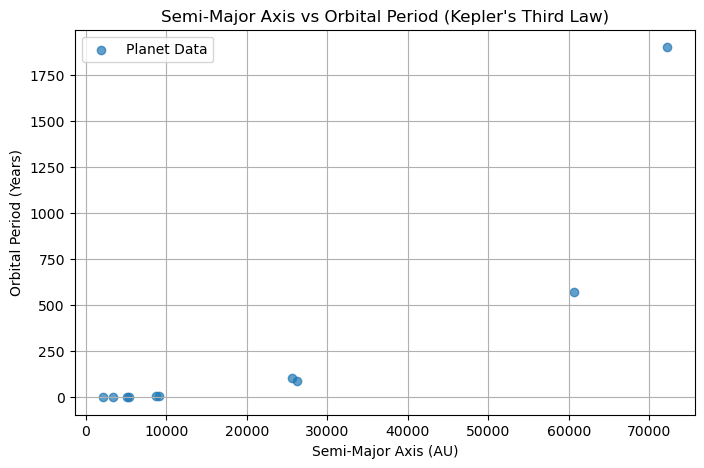

Fitted model: T = 0.00 * a^(3/2)


In [9]:
# Plot axis vs period
plt.figure(figsize=(8,5))
plt.scatter(semi_major_axis, orbital_period, label='Planet Data', alpha=0.7)

plt.xlabel("Semi-Major Axis (AU)")   # AU = Astronomical Units
plt.ylabel("Orbital Period (Years)")
plt.title("Semi-Major Axis vs Orbital Period (Kepler's Third Law)")
plt.legend()
plt.grid(True)
plt.show()

def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]

print(f"Fitted model: T = {m_fit:.2f} * a^(3/2)")

Reduced Chi-Squared: 66815.87


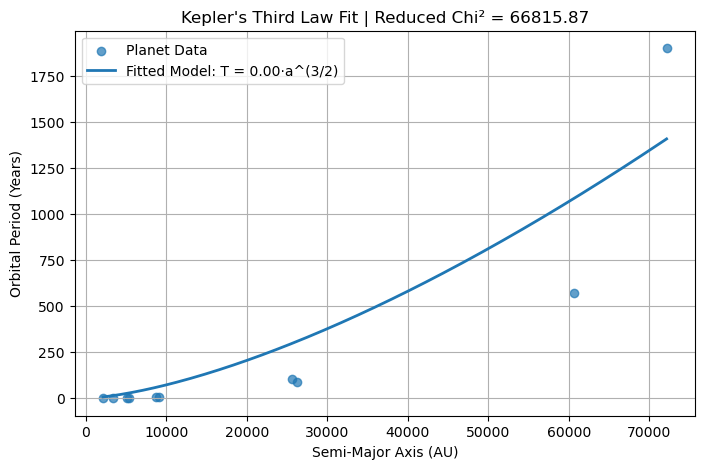

In [12]:
# Residuals
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)

# Chi-squared
chi2 = np.sum(residuals**2)

# Degrees of freedom
dof = len(semi_major_axis) - 1
chi2_reduced = chi2 / dof

print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")

# plot fitted line
a_fit_line = np.linspace(min(semi_major_axis), max(semi_major_axis), 200)
T_fit_line = keplers_third_law(a_fit_line, m_fit)

plt.figure(figsize=(8,5))

plt.scatter(semi_major_axis, orbital_period, label='Planet Data', alpha=0.7)

plt.plot(a_fit_line, T_fit_line, label=f'Fitted Model: T = {m_fit:.2f}·a^(3/2)', linewidth=2)

plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (Years)")
plt.title(f"Kepler's Third Law Fit | Reduced Chi² = {chi2_reduced:.2f}")
plt.legend()
plt.grid(True)
plt.show()

df.to_csv("kepler.csv", index=False)